In [ ]:
# @title
from IPython.display import display, HTML

display(HTML("""
<div style="
    display: flex;
    align-items: center;
    justify-content: space-between;
    font-family: 'Poppins', sans-serif;
    padding: 20px;
">

    <!-- Left Section: Title -->
    <div style="width: 50%; text-align: left;">
        <h1 style="
            font-size: 40px;
            margin: 0;
            background: linear-gradient(90deg, #00c6ff, #0072ff);
            -webkit-background-clip: text;
            -webkit-text-fill-color: transparent;
        ">
            Hotel Reviews Sentiment Analysis
        </h1>
    </div>

    <!-- Right Section: Image -->
    <div style="width: 45%; text-align: right;">
        <div style="
            background: white;
            padding: 10px;
            border-radius: 12px;
            display: inline-block;
        ">
            <img src="https://www.reviewtrackers.com/wp-content/uploads/Hotel-Reviews.jpg"
                 width="100%"
                 style="border-radius: 8px;">
        </div>
    </div>

</div>
"""))

# **📊 Dataset Description**

### 🔗Data Source
- 515K Hotel Reviews Data in Europe (Kaggle)  
- Link: https://www.kaggle.com/datasets/jiashenliu/515k-hotel-reviews-data-in-europe/data  

📌 Description:  
This dataset contains around 515,000 customer reviews and ratings for 1,493 hotels across Europe.  


---

### 📁 Columns Description

| Column | Explanation |
|--------|------------|
| Hotel_Address | Full address of the hotel |
| Additional_Number_of_Scoring | Number of ratings without written reviews |
| Review_Date | Date when the review was posted |
| Average_Score | Average score of the hotel based on reviews |
| Hotel_Name | Name of the hotel |
| Reviewer_Nationality | Nationality of the reviewer |
| Negative_Review | Negative feedback text (or "No Negative") |
| Review_Total_Negative_Word_Counts | Number of words in the negative review |
| Total_Number_of_Reviews | Total number of reviews for the hotel |
| Positive_Review | Positive feedback text (or "No Positive") |
| Review_Total_Positive_Word_Counts | Number of words in the positive review |
| Total_Number_of_Reviews_Reviewer_Has_Given | Number of reviews written by the reviewer |
| Reviewer_Score | Score given by the reviewer |
| Tags | Trip-related info (trip type, group type, stay duration) |
| days_since_review | Number of days between review date and data collection |
| lat | Latitude of the hotel |
| lng | Longitude of the hotel |

#**EDA**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Hotel_Reviews.csv')

In [ ]:
#!pip install ydata-profiling

In [ ]:
import pandas_profiling

profile = pandas_profiling.ProfileReport(df)
profile.to_file(output_file='report.html')

/tmp/ipykernel_8171/2593077033.py:1: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  import pandas_profiling


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:59<00:00,  3.52s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [1]:
#profile

In [ ]:
df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [ ]:
df.columns

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng'],
      dtype='object')

In [ ]:
df = df.rename(columns={
    'Total_Number_of_Reviews_Reviewer_Has_Given': 'reviewer_activity'
})

In [ ]:
df.shape

(515738, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Hotel_Address                      515738 non-null  object 
 1   Additional_Number_of_Scoring       515738 non-null  int64  
 2   Review_Date                        515738 non-null  object 
 3   Average_Score                      515738 non-null  float64
 4   Hotel_Name                         515738 non-null  object 
 5   Reviewer_Nationality               515738 non-null  object 
 6   Negative_Review                    515738 non-null  object 
 7   Review_Total_Negative_Word_Counts  515738 non-null  int64  
 8   Total_Number_of_Reviews            515738 non-null  int64  
 9   Positive_Review                    515738 non-null  object 
 10  Review_Total_Positive_Word_Counts  515738 non-null  int64  
 11  reviewer_activity                  5157

In [ ]:
df.describe()

,Additional_Number_of_Scoring,Average_Score,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,reviewer_activity,Reviewer_Score,lat,lng
count,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,512470.000000,512470.000000
mean,498.081836,8.397487,18.539450,2743.743944,17.776458,7.166001,8.395077,49.442439,2.823803
std,500.538467,0.548048,29.690831,2317.464868,21.804185,11.040228,1.637856,3.466325,4.579425
min,1.000000,5.200000,0.000000,43.000000,0.000000,1.000000,2.500000,41.328376,-0.369758
25%,169.000000,8.100000,2.000000,1161.000000,5.000000,1.000000,7.500000,48.214662,-0.143372
50%,341.000000,8.400000,9.000000,2134.000000,11.000000,3.000000,8.800000,51.499981,0.010607
75%,660.000000,8.800000,23.000000,3613.000000,22.000000,8.000000,9.600000,51.516288,4.834443
max,2682.000000,9.800000,408.000000,16670.000000,395.000000,355.000000,10.000000,52.400181,16.429233


In [ ]:
df.describe(include='object')

,Hotel_Address,Review_Date,Hotel_Name,Reviewer_Nationality,Negative_Review,Positive_Review,Tags,days_since_review
count,515738,515738,515738,515738,515738,515738,515738,515738
unique,1493,731,1492,227,330011,412601,55242,731
top,163 Marsh Wall Docklands Tower Hamlets London ...,8/2/2017,Britannia International Hotel Canary Wharf,United Kingdom,No Negative,No Positive,"[' Leisure trip ', ' Couple ', ' Double Room '...",1 days
freq,4789,2585,4789,245246,127890,35946,5101,2585


In [ ]:
df.duplicated().sum()

np.int64(526)

In [ ]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [ ]:
missing = (df.isnull().mean() * 100).round(2)

missing[missing > 0]

,0
lat,0.63
lng,0.63


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.shape

(511944, 17)

In [ ]:
df.dtypes

,0
Hotel_Address,object
Additional_Number_of_Scoring,int64
Review_Date,object
Average_Score,float64
Hotel_Name,object
Reviewer_Nationality,object
Negative_Review,object
Review_Total_Negative_Word_Counts,int64
Total_Number_of_Reviews,int64
Positive_Review,object


In [ ]:
df['Review_Date'] = pd.to_datetime(df['Review_Date'])

In [ ]:
df['days_since_review'].head()

,days_since_review
0,0 days
1,0 days
2,3 days
3,3 days
4,10 days


In [ ]:
df['days_since_review'] = df['days_since_review'].str.extract('(\d+)').astype(int)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1537/269679632.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['days_since_review'] = df['days_since_review'].str.extract('(\d+)').astype(int)


In [ ]:
df['days_since_review'].head()

,days_since_review
0,0
1,0
2,3
3,3
4,10


#**⚙️ Feature Engineering**

In [ ]:
df['year'] = df['Review_Date'].dt.year
df['month'] = df['Review_Date'].dt.month
df['day_of_week'] = df['Review_Date'].dt.dayofweek

In [ ]:
df['full_review'] = df['Positive_Review'] + " " + df['Negative_Review']

In [ ]:
import ast
import re

# تحويل Tags إلى list
df['Tags_list'] = df['Tags'].apply(ast.literal_eval)
df['Tags_list'] = df['Tags_list'].apply(lambda x: [t.strip() for t in x])

# Features بسيطة
df['is_leisure_trip'] = df['Tags'].str.contains('Leisure trip').astype(int)
df['is_business_trip'] = df['Tags'].str.contains('Business trip').astype(int)
df['is_family'] = df['Tags'].str.contains('Family').astype(int)
df['is_solo'] = df['Tags'].str.contains('Solo traveler').astype(int)
df['is_couple'] = df['Tags'].str.contains('Couple').astype(int)

# عدد الليالي
def extract_nights(tags):
    for tag in tags:
        if "Stayed" in tag:
            return int(re.findall(r'\d+', tag)[0])
    return None

df['nights_stayed'] = df['Tags_list'].apply(extract_nights)

# هل من موبايل
df['is_mobile'] = df['Tags'].str.contains('mobile', case=False).astype(int)

In [ ]:
df.isnull().sum().sum()

np.int64(191)

In [ ]:
df['nights_stayed'] = df['nights_stayed'].fillna(df['nights_stayed'].median())

#**📈Univariate Analysis**

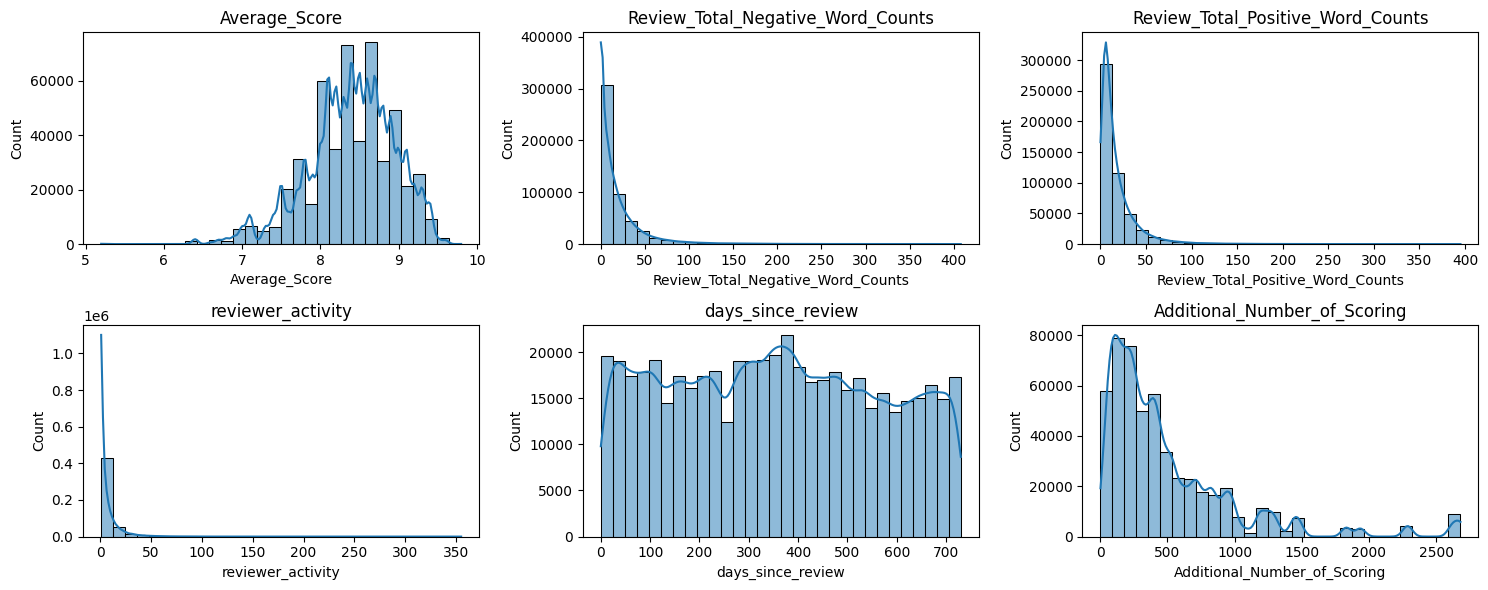

In [ ]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Select useful numeric columns only
num_cols = [
    'Average_Score',
    'Review_Total_Negative_Word_Counts',
    'Review_Total_Positive_Word_Counts',
    'reviewer_activity',
    'days_since_review',
    'Additional_Number_of_Scoring'
]

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(15, n_rows * 3))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

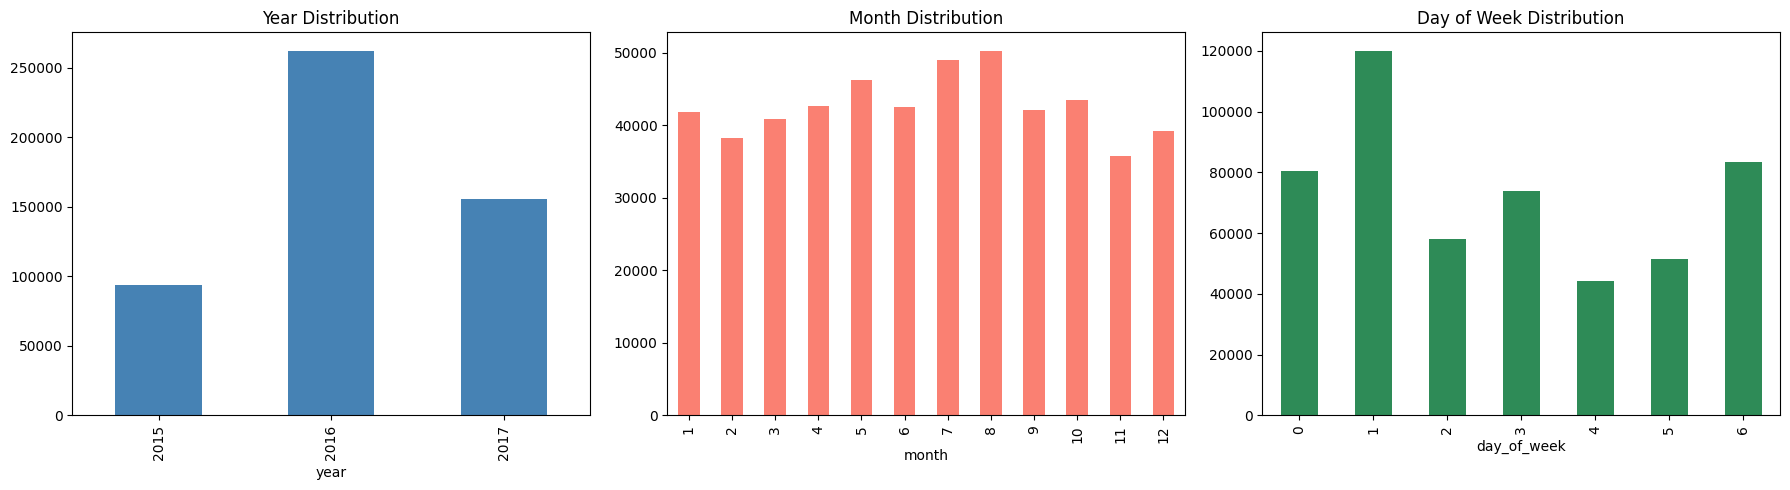

In [ ]:
# @title
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Year
df['year'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title('Year Distribution')

# Month
df['month'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[1],
    color='salmon'
)
axes[1].set_title('Month Distribution')

# Day of Week
df['day_of_week'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[2],
    color='seagreen'
)
axes[2].set_title('Day of Week Distribution')

plt.tight_layout()
plt.show()

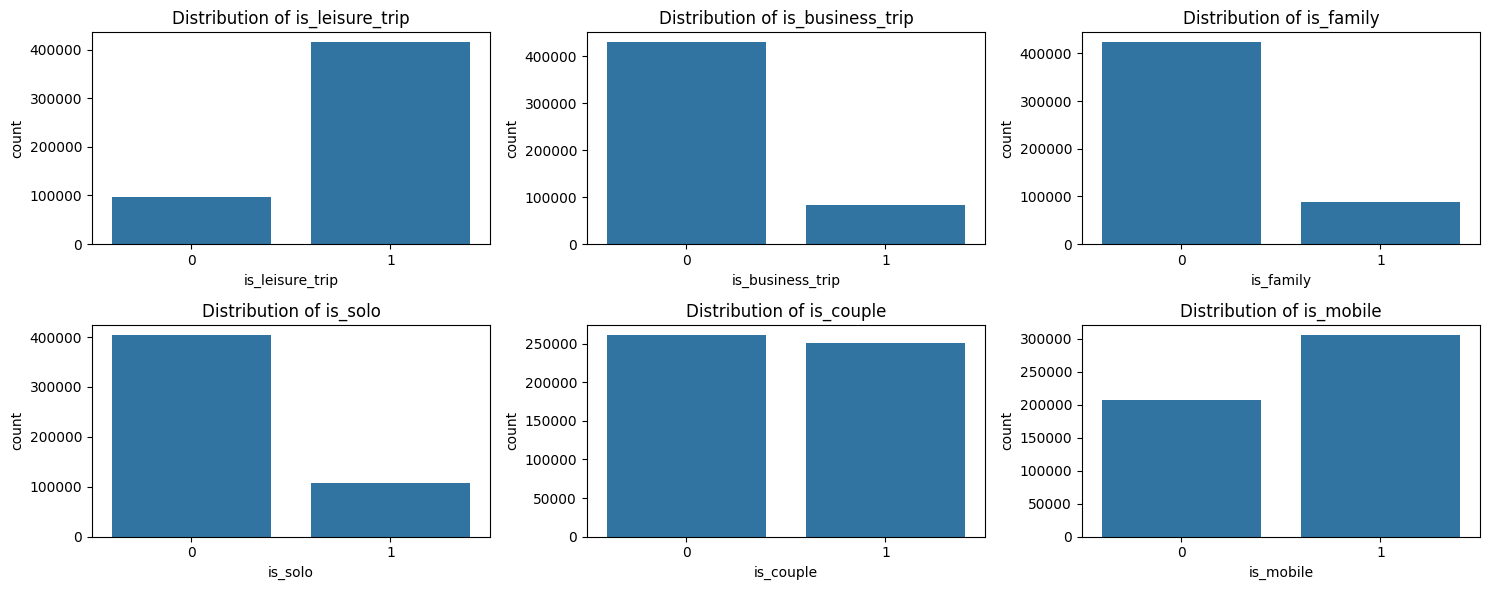

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

binary_cols = [
    'is_leisure_trip',
    'is_business_trip',
    'is_family',
    'is_solo',
    'is_couple',
    'is_mobile'
]

plt.figure(figsize=(15, n_rows * 3))

for i, col in enumerate(binary_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=df[col])
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [ ]:
cat_cols = df[['Hotel_Address','Hotel_Name', 'Reviewer_Nationality','Negative_Review','Positive_Review', 'Tags']]

for col in cat_cols:
    print(f"\n===== {col} =====")
    display(df[col].value_counts().head(10))


===== Hotel_Address =====


,count
Hotel_Address,
163 Marsh Wall Docklands Tower Hamlets London E14 9SJ United Kingdom,4789
372 Strand Westminster Borough London WC2R 0JJ United Kingdom,4256
Westminster Bridge Road Lambeth London SE1 7UT United Kingdom,4169
Scarsdale Place Kensington Kensington and Chelsea London W8 5SY United Kingdom,3577
7 Pepys Street City of London London EC3N 4AF United Kingdom,3212
1 Inverness Terrace Westminster Borough London W2 3JP United Kingdom,2958
Wrights Lane Kensington and Chelsea London W8 5SP United Kingdom,2768
225 Edgware Road Westminster Borough London W2 1JU United Kingdom,2628
4 18 Harrington Gardens Kensington and Chelsea London SW7 4LH United Kingdom,2565



===== Hotel_Name =====


,count
Hotel_Name,
Britannia International Hotel Canary Wharf,4789
Strand Palace Hotel,4256
Park Plaza Westminster Bridge London,4169
Copthorne Tara Hotel London Kensington,3577
DoubleTree by Hilton Hotel London Tower of London,3212
Grand Royale London Hyde Park,2958
Holiday Inn London Kensington,2768
Hilton London Metropole,2628
Millennium Gloucester Hotel London,2565



===== Reviewer_Nationality =====


...

,count
Negative_Review,
No Negative,126902
Nothing,14220
Nothing,4209
nothing,2206
N A,1031
None,978
,835
N a,506
Breakfast,405



===== Positive_Review =====


,count
Positive_Review,
No Positive,35695
Location,9169
Everything,2277
location,1670
Nothing,1233
The location,1116
Great location,1040
Good location,924
Location,910



===== Tags =====


,count
Tags,
"[' Leisure trip ', ' Couple ', ' Double Room ', ' Stayed 1 night ', ' Submitted from a mobile device ']",5100
"[' Leisure trip ', ' Couple ', ' Standard Double Room ', ' Stayed 1 night ', ' Submitted from a mobile device ']",4905
"[' Leisure trip ', ' Couple ', ' Superior Double Room ', ' Stayed 1 night ', ' Submitted from a mobile device ']",4348
"[' Leisure trip ', ' Couple ', ' Deluxe Double Room ', ' Stayed 1 night ', ' Submitted from a mobile device ']",3986
"[' Leisure trip ', ' Couple ', ' Double Room ', ' Stayed 2 nights ', ' Submitted from a mobile device ']",3285
"[' Leisure trip ', ' Couple ', ' Superior Double Room ', ' Stayed 2 nights ', ' Submitted from a mobile device ']",3064
"[' Leisure trip ', ' Couple ', ' Double Room ', ' Stayed 1 night ']",2903
"[' Leisure trip ', ' Couple ', ' Standard Double Room ', ' Stayed 2 nights ', ' Submitted from a mobile device ']",2901
"[' Leisure trip ', ' Couple ', ' Standard Double Room ', ' Stayed 1 night ']",2587


#**📉Bivariate Analysis**

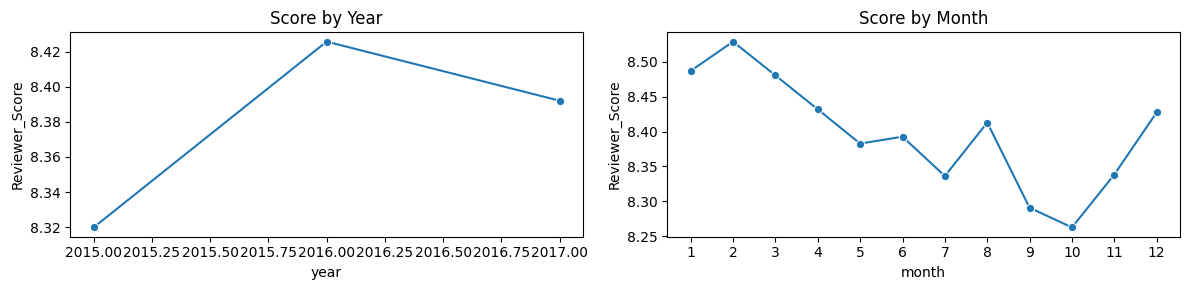

In [ ]:
# @title
yearly = df.groupby('year')['Reviewer_Score'].mean().reset_index()
monthly = df.groupby('month')['Reviewer_Score'].mean().reset_index()

plt.figure(figsize=(12,3))

# Year
plt.subplot(1, 2, 1)
sns.lineplot(data=yearly, x='year', y='Reviewer_Score', marker='o')
plt.title("Score by Year")

# Month
plt.subplot(1, 2, 2)
sns.lineplot(data=monthly, x='month', y='Reviewer_Score', marker='o')
plt.title("Score by Month")
plt.xticks(range(1,13))

plt.tight_layout()
plt.show()

#**📊Multivariate Analysis**

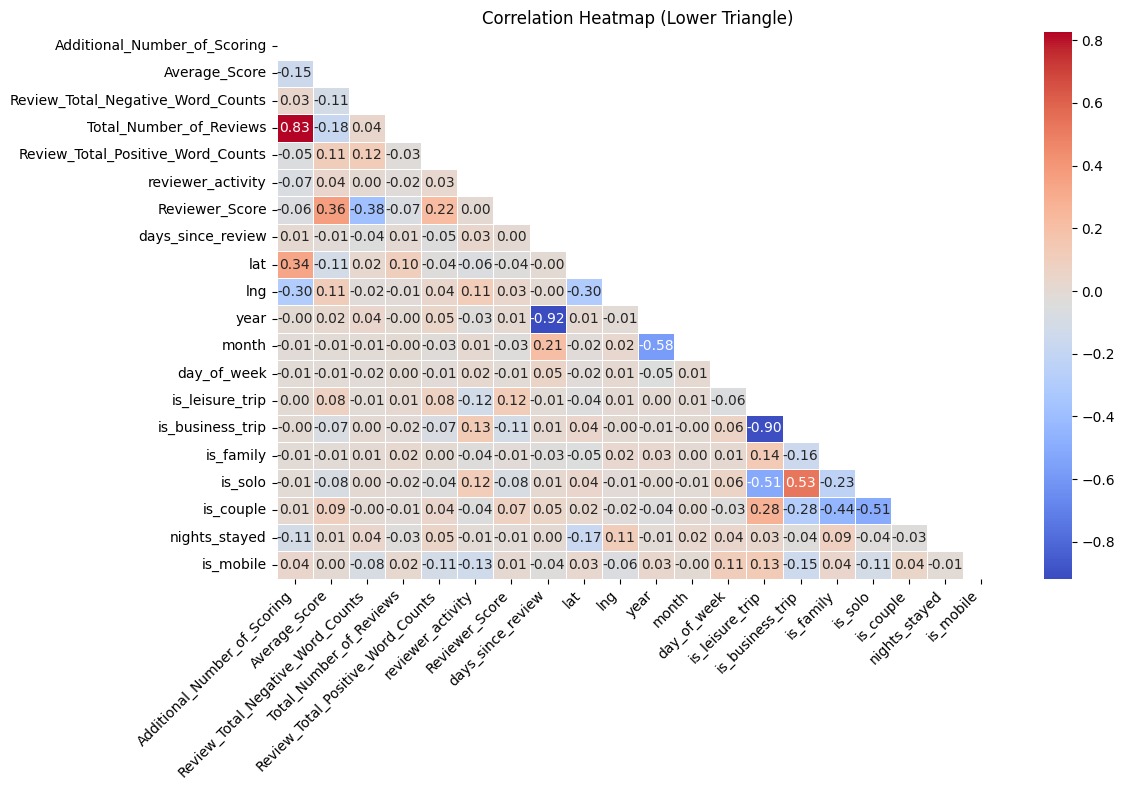

In [ ]:
import numpy as np

# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar=True
)

plt.title("Correlation Heatmap (Lower Triangle)")

# Rotate labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
df['Hotel_Address'].sample(5)

,Hotel_Address
224150,61 Lincoln s Inn Fields Camden London WC2A 3JW...
473180,Via della Giustizia 10 D Bicocca Zara 20125 Mi...
57069,150 Bayswater Road Kensington and Chelsea Lond...
77494,18 Lodge Road Near Baker Street And Marylebone...
91009,2 Rue Saint Sulpice 6th arr 75006 Paris France


In [ ]:
df['city'] = df['Hotel_Address'].apply(lambda x: x.split()[-2])
df['city'].value_counts().head()

,count
city,
United,262298
Barcelona,59942
Paris,59031
Amsterdam,57211
Milan,37204


In [ ]:
city_scores = df.groupby('city')['Reviewer_Score'].mean().sort_values(ascending=False)

city_scores.head(10)

,Reviewer_Score
city,
Vienna,8.567158
Barcelona,8.553839
Amsterdam,8.456230
Paris,8.423113
Milan,8.346678
United,8.324130


#**Distribution of Target Variable**

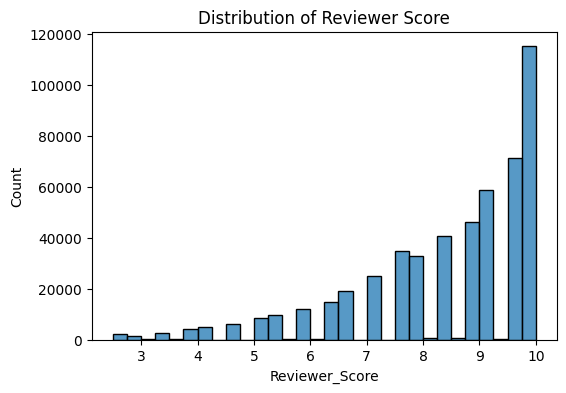

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Reviewer_Score'], bins=30)
plt.title("Distribution of Reviewer Score")
plt.show()

In [ ]:
df['sentiment'] = df['Reviewer_Score'].apply(
    lambda x: 'positive' if x >= 8 else 'negative'
)

In [ ]:
round(df['sentiment'].value_counts(normalize=True), 2)

,proportion
sentiment,
positive,0.65
negative,0.35


#**Drop columns**

In [ ]:
drop_cols = [
    'Hotel_Address',
    'Hotel_Name',
    'Tags',
    'Tags_list',
    'Positive_Review',
    'Negative_Review',
    'Review_Date',
    'Reviewer_Score',   # 🚨 مهم جدًا يتشال
    'lat',
    'lng'
]

df = df.drop(columns=drop_cols)

In [ ]:
df.columns

Index(['Additional_Number_of_Scoring', 'Average_Score', 'Reviewer_Nationality',
       'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews',
       'Review_Total_Positive_Word_Counts', 'reviewer_activity',
       'days_since_review', 'year', 'month', 'day_of_week', 'full_review',
       'is_leisure_trip', 'is_business_trip', 'is_family', 'is_solo',
       'is_couple', 'nights_stayed', 'is_mobile', 'city', 'sentiment'],
      dtype='object')

In [ ]:
df.shape[1]

21

#**Split Data✂️**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('sentiment', axis=1)
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y )

In [ ]:
print("Train distribution:")
display(round(y_train.value_counts(normalize=True), 2))

print("\nTest distribution:")
display(round(y_test.value_counts(normalize=True), 2))

Train distribution:


,proportion
sentiment,
positive,0.65
negative,0.35



Test distribution:


,proportion
sentiment,
positive,0.65
negative,0.35


#**Numerical Feature Transformations**


In [ ]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns

continuous_cols = [col for col in num_cols if col not in binary_cols]

skewed_cols = X_train[continuous_cols].skew().sort_values(ascending=False)
skewed_cols

,0
reviewer_activity,5.165601
Review_Total_Negative_Word_Counts,4.406561
Review_Total_Positive_Word_Counts,4.197802
nights_stayed,2.544964
Additional_Number_of_Scoring,2.198537
Total_Number_of_Reviews,2.079446
days_since_review,0.055470
Average_Score,-0.548179


In [ ]:
import numpy as np

log_cols = [
    'reviewer_activity',
    'Review_Total_Negative_Word_Counts',
    'Review_Total_Positive_Word_Counts',
    'nights_stayed',
    'Additional_Number_of_Scoring',
    'Total_Number_of_Reviews'
]

for col in log_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

#**Encoding**

In [ ]:
X_train.select_dtypes(include='object').columns

Index(['Reviewer_Nationality', 'full_review', 'city'], dtype='object')

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe_cols = ['city']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_train = encoder.fit_transform(X_train[ohe_cols])
encoded_test = encoder.transform(X_test[ohe_cols])

encoded_train_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(ohe_cols), index=X_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(ohe_cols), index=X_test.index)

# drop original + concat
X_train = X_train.drop(columns=ohe_cols).join(encoded_train_df)
X_test = X_test.drop(columns=ohe_cols).join(encoded_test_df)

In [ ]:
freq_map = X_train['Reviewer_Nationality'].value_counts(normalize=True)

X_train['Reviewer_Nationality'] = X_train['Reviewer_Nationality'].map(freq_map)
X_test['Reviewer_Nationality'] = X_test['Reviewer_Nationality'].map(freq_map).fillna(0)

In [ ]:
set(X_train.columns) == set(X_test.columns)

True

In [ ]:
X_train.isnull().sum().sum(), X_test.isnull().sum().sum()

(np.int64(0), np.int64(0))

#**scale numeric features**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()

# Apply scaling only to numerical columns
X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled = scaler.transform(X_test[numerical_cols])

# Convert scaled arrays back to DataFrames, preserving column names and index
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numerical_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numerical_cols, index=X_test.index)

# Replace original numerical columns with scaled ones in X_train and X_test
X_train = X_train.drop(columns=numerical_cols).join(X_train_scaled_df)
X_test = X_test.drop(columns=numerical_cols).join(X_test_scaled_df)

#**Save CSV**

In [ ]:
import os

path = "/content/drive/MyDrive/Hotel_Reviews_Project"

os.makedirs(path, exist_ok=True)

In [ ]:
X_train.to_csv(f"{path}/X_train_clean.csv", index=False)
X_test.to_csv(f"{path}/X_test_clean.csv", index=False)

y_train.to_csv(f"{path}/y_train_clean.csv", index=False)
y_test.to_csv(f"{path}/y_test_clean.csv", index=False)